In [4]:
import os, sys
import numpy as np
import torch
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sys.path.append('../')
from STARMap.utils import *
from STARMap.preprocess import *
from STARMap.STARMap_pyG import Train_STARMap

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

os.environ.setdefault('LANG', 'en_US.UTF-8')
os.environ.setdefault('LC_ALL', 'en_US.UTF-8')

r_home = detect_r_home()
mclust_ready = check_mclust(install_if_missing=False)
if mclust_ready:
    print('mclust OK')

R_HOME set to: D:/Anaconda/envs/spatialglue/lib/R
mclust OK


In [5]:
file_fold = '../Data/Human_Lymph_Node/'
rna_file = file_fold + 'adata_RNA.h5ad'
adt_file = file_fold + 'adata_ADT.h5ad'
scgpt_file = file_fold + 'scGPT_embedding.npy'
ground_truth_path = file_fold + 'GT_labels.txt'

adata_omics1 = sc.read_h5ad(rna_file)
adata_omics2 = sc.read_h5ad(adt_file)
adata_omics2 = align_adata_to_obs_names(adata_omics2, adata_omics1.obs_names)

scgpt_embedding = np.load(scgpt_file)
adata_omics3 = build_embedding_adata(
    scgpt_embedding,
    reference_adata=adata_omics1,
    var_prefix='scGPT',
    spatial_key='spatial',
)

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

data_type = '10x'
random_seed = 2022
fix_seed(random_seed)

d:\Anaconda\envs\spatialglue\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
n_top_hvg = 2000
n_top_svg = 0
svg_neighbors = 6

prep_results = prepare_starmap_modalities(
    adata_omics1,
    adata_omics2,
    adata_omics3=adata_omics3,
    n_top_hvg=n_top_hvg,
    n_top_svg=n_top_svg,
    min_cells=10,
    spatial_key='spatial',
    svg_neighbors=svg_neighbors,
)
adata_omics1 = prep_results['adata_omics1']
adata_omics2 = prep_results['adata_omics2']
adata_omics3 = prep_results['adata_omics3']
selected_gene_mask = prep_results['selected_gene_mask']

HVG genes: 2000
SVG genes: 0
HVG | SVG genes: 2000


d:\Anaconda\envs\spatialglue\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [7]:
data = construct_neighbor_graph(adata_omics1, adata_omics2, adata_omics3, datatype=data_type)
model = Train_STARMap(
    data,
    datatype=data_type,
    device=device,
)
output = model.train()

e:\statistical modeling\model\Pipeline\..\STARMap\preprocess.py:607: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\bld\libtorch_1762156908853\work\torch\csrc\utils\tensor_new.cpp:655.)
  return torch.sparse.FloatTensor(indices, values, shape)
100%|██████████| 200/200 [00:36<00:00,  5.46it/s]

Model training finished!



In [8]:
adata = adata_omics1.copy()
attach_obsm_from_dict(
    adata,
    output,
    keys=[
        'emb_latent_omics1',
        'emb_latent_omics2',
        'emb_latent_omics3',
        'STARMap',
        'alpha',
        'alpha_omics1',
        'alpha_omics2',
        'alpha_omics3',
    ],
)

['emb_latent_omics1',
 'emb_latent_omics2',
 'emb_latent_omics3',
 'STARMap',
 'alpha',
 'alpha_omics1',
 'alpha_omics2',
 'alpha_omics3']

In [13]:
key = 'STARMap'
truth_key = 'ground_truth'
n_clusters = 6
method = 'mclust'

cluster_eval = run_embedding_clustering_evaluation(
    adata,
    embedding_key=key,
    label_path=ground_truth_path,
    n_clusters=n_clusters,
    method=method,
    truth_key=truth_key,
    pca_n_comps=30,
    random_seed=random_seed,
    pred_key=key,
)

scores_mclust = cluster_eval['scores']
labels_true = cluster_eval['labels_true']
label_order = cluster_eval['label_order']
confusion_mclust = cluster_eval['confusion']

fitting ...
  |======================================================================| 100%


In [14]:
print(pd.Series(scores_mclust, name='mclust_global').round(4).to_string())

ARI                   0.3208
NMI                   0.4252
AMI                   0.4228
Homogeneity Score     0.4049
Completeness Score    0.4477
V-Measure             0.4252


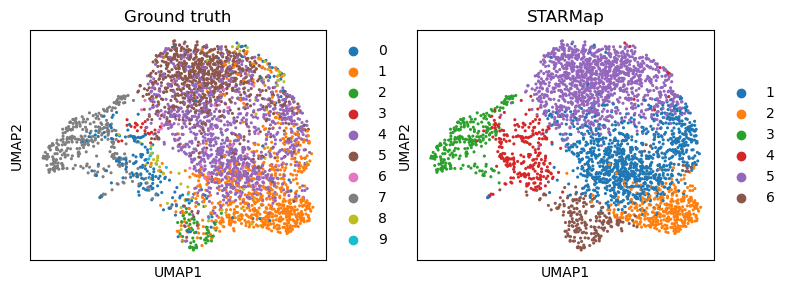

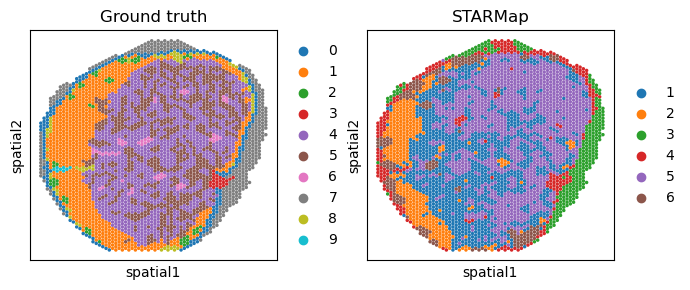

(<Figure size 700x300 with 2 Axes>,
 array([<Axes: title={'center': 'Ground truth'}, xlabel='spatial1', ylabel='spatial2'>,
        <Axes: title={'center': 'STARMap'}, xlabel='spatial1', ylabel='spatial2'>],
       dtype=object))

In [16]:
plot_umap_ground_truth_vs_prediction(
    adata,
    pred_key=key,
    truth_key='ground_truth',
    use_rep='STARMap',
    n_neighbors=10,
    figsize=(8, 3),
    point_size=20,
    pred_title='STARMap',
)

plot_spatial_cluster_comparison(
    adata,
    pred_key=key,
    truth_key='ground_truth',
    pred_title='STARMap',
)

fitting ...
  |======================================================================| 100%
Rare label 3: n=23, frac=0.66%, best_cluster=14, F1=0.365, MCC=0.451


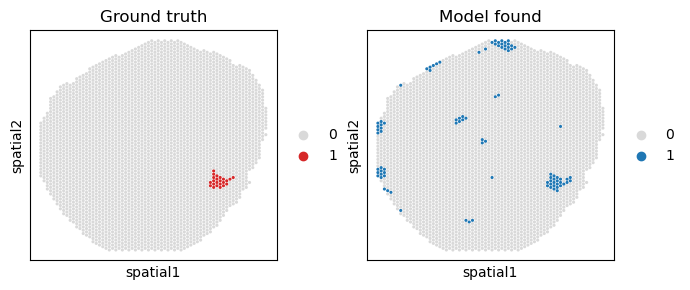

Rare label 6: n=57, frac=1.64%, best_cluster=2, F1=0.104, MCC=0.111


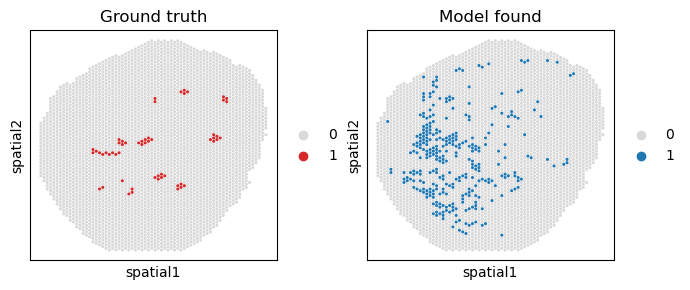

Rare label 2: n=60, frac=1.72%, best_cluster=12, F1=0.583, MCC=0.605


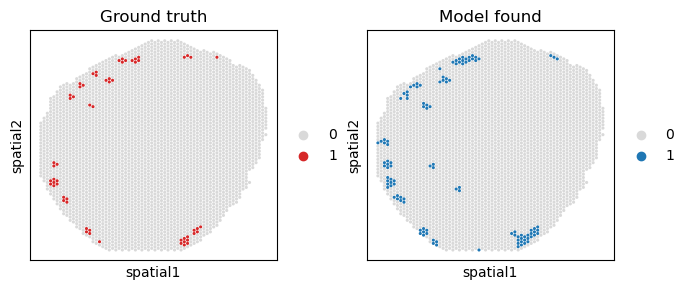

Rare label 8: n=74, frac=2.12%, best_cluster=6, F1=0.168, MCC=0.150


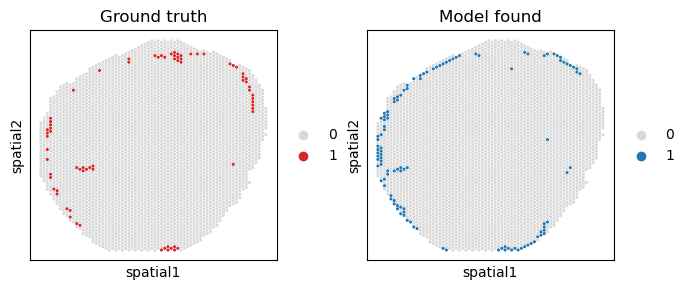

In [18]:
from STARMap.utils import summarize_best_matching_clusters, plot_rare_truth_vs_best_cluster_panels

rare_key = f"{key}_17"
_ = run_embedding_clustering_evaluation(
    adata,
    embedding_key=key,
    label_path=ground_truth_path,
    n_clusters=17,
    method=method,
    truth_key=truth_key,
    pca_n_comps=20,
    random_seed=random_seed,
    pred_key=rare_key,
)

_, rare_summary, _ = summarize_best_matching_clusters(
    adata,
    pred_key=rare_key,
    truth_key=truth_key,
    selection_metric="f1",
    exclude_truth_labels=['9'],
    rare_fraction_threshold=0.05
)

if not rare_summary.empty:
    _ = plot_rare_truth_vs_best_cluster_panels(
        adata, 
        rare_summary,
        label_key=truth_key, 
        pred_key=rare_key,
        basis='spatial',
        figsize=(7, 3),
        spatial_point_size=20
    )